<a href="https://colab.research.google.com/github/properallan/ENE300/blob/main/tarefas/trabalho_1/trabalho_1_entrega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução


Deseja-se construir uma caixa com uma folha de papelão tamanho A4 ($210\times297$ mm), que possibilite armazenar o maior volume possível. A função $f$ modela o volume dessa caixa em função da espessura das margens, denotado por $x$. Dessa forma o problema pode ser forumalado como um problema de otimização, onde o objetivo é maximizar a funcão

$$
f(x) = 4x^3-1014x^2+62370x
$$

, sujeita à restrição 

$$
0 \leq x \leq 105
$$

A Figura a seguir apresenta graficamente a modelagem do problema. A restrição para o esse problema é obtida notando-se que nenhum dos comprimentos pode ser menor que zero e portanto

<center>
  <img src="https://github.com/properallan/ENE300/blob/main/tarefas/trabalho_1/A4.png?raw=1" width=40% style="margin-left:auto; margin-right:auto">
</center>


O problema em questão pode ser resolvido analiticamente, sabendo que o máximo para a função $f(x)$ ocorre em um ponto onde a derivada é nula

$$
\frac{df}{dx} = 12x^2-2028x+62370 = 0
$$

As duas raíves reais são 

$$
\begin{align}
x_1 =&  \frac{169}{2} - \frac{\sqrt{7771}}{2} \approx 40.42 \\
x_2 =&  \frac{169}{2} + \frac{\sqrt{7771}}{2} \approx 128.58
\end{align}
$$

Como a solução $x_2$ viola a restrição $x\leq105$ a possível solução para o problema é $x_1$, restando determinar se o ponto é realmente de máximo, analisando a segunda derifada da função

$$
\frac{d^2 f}{dx^2} \bigg\rvert_{x_1} = 24x-2028 \bigg\rvert_{x_1} = -1057.84
$$

, como $ \frac{d^2 f}{dx^2} \bigg\rvert_{x_1} < 0$, $x_1$ é ponto de máximo e portanto solução do problema propostos. Pela sua simplicidade o problema também poderia ser resolvido graficamente. 

A função `f(x)` é a implementação direta da função objetivo $f(x)$.

In [57]:
def f(x):
    return 4*x**3-1014*x**2+62370*x

Define-se um domínio discreto para a função $f$, como a função $f$ está definida em todo o domínio dos números reais, o domínio foi arbitrariamente escolhido no intervalo $-10 ≤ x ≤ 200$.



In [58]:
import numpy as np
x = np.linspace(-10, 200, 100)

Para a análise gráfica, plotamos o domínio viável de soluções representado pela região delimitada pelas restrições. Por meio de inspeção visual é possível estimar um valor candidato à ótimo em $x=40$. Apesar da simplicidade e eficacácia do método, ele pode tornar-se inviável para funções de multiplas variáveis e muitas restrições. Em geral deseja-se utilizar métodos numéricos, com algoritmos capazes de contornar esses problemas. Vamos estudar a *Busca Dicontômica*, *Método da Bissecção* e *Método de Newton*.

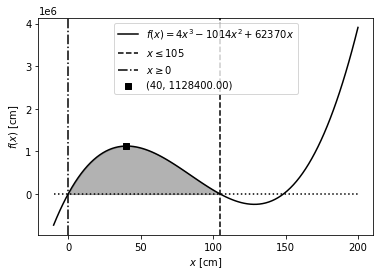

In [104]:
import matplotlib.pyplot as plt

# plot function
plt.plot(x, f(x), c='k', label=rf'$f(x)=4x^3-1014x^2+62370x$')

# plot restrictions
plt.plot(x, np.zeros_like(x), c='k', ls=':')
plt.axvline(105, c='k', ls='--', label=rf'$x \leq 105$')
plt.axvline(0, c='k', ls='-.', label=rf'$x \geq 0$')

# plot viable solutions
plt.fill_between(x, 0, f(x), where=((x>=0) & (x<=105)), color='k', alpha=0.3)
plt.xlabel(rf'$x$ [cm]')
plt.ylabel(rf'$f(x)$ [cm]')

# plot optimum solution
x_opt = 40
plt.scatter(x_opt, f(x_opt), marker='s', c='k', label=rf'(40, {f(x_opt):.2f})')

plt.legend()


# Busca Dicotîmica

O método de *Busca Dicontômica* divide, a cada nova iteração, o intervalo de busca pela metade. Com a escolha adequada de $a, b$ e $\epsilon$ o método irá convergir para o mínimo da função $f$, se $f$ form unimodal no intervalo $[a,b
]$, ou seja, se $f$ atinge o mínimo global $x^* \in \;]a,b[$ e para quaisquer $x_1,x_2 \in [a,b]$, verificar-se que

$$
\begin{align}
f(x_2) < f(x_1) \qquad &, se \; x_1 < x_2 < x^* \\
f(x_1) < f(x_2) \qquad &, se \; x^* < x_1 < x_2 
\end{align}
$$





In [ ]:
def dichotomous_search(f, a, b, epsilon):
    print(f"it \ta \tb \tintervalo  \tx1 \tx2 \tf_x1   \tf_x2")
    it = 0
    while abs(a - b) >= epsilon*10.0:
        x1 = (a + b)/2.0 - epsilon
        x2 = (a + b)/2.0 + epsilon
        f_x1 = f(x1)
        f_x2 = f(x2)
        if f_x1 > f_x2:
            a = x1
        else:
            b = x2

        it += 1
        erro = abs(a-b)
        
        print(f"{it} \t{a:.4f} \t{b:.4f} \t{erro:.4f}  \t{x1:.4f} \t{x2:.4f} \t{f_x1:.4f} \t{f_x2:.4f}")
    return (a + b) / 2.0

In [ ]:
f_ = lambda x: -f(x)

In [ ]:
dichotomous_search(f_, 0.0, 105.0 , 0.00001)

it 	a 	b 	intervalo  	x1 	x2 	f_x1   	f_x2
1 	0.0000 	52.5000 	52.5000  	52.5000 	52.5000 	-1058400.1102 	-1058399.8897
2 	26.2500 	52.5000 	26.2500  	26.2500 	26.2500 	-1010854.6005 	-1010854.9486
3 	39.3750 	52.5000 	13.1250  	39.3750 	39.3750 	-1127909.1713 	-1127909.1937
4 	39.3750 	45.9375 	6.5625  	45.9375 	45.9375 	-1113083.6172 	-1113083.5078
5 	39.3750 	42.6563 	3.2813  	42.6562 	42.6563 	-1125902.5730 	-1125902.5270
6 	39.3750 	41.0156 	1.6406  	41.0156 	41.0156 	-1128310.4087 	-1128310.3962
7 	40.1953 	41.0156 	0.8203  	40.1953 	40.1953 	-1128467.5481 	-1128467.5529
8 	40.1953 	40.6055 	0.4102  	40.6055 	40.6055 	-1128477.5899 	-1128477.5861
9 	40.4004 	40.6055 	0.2051  	40.4004 	40.4004 	-1128494.8254 	-1128494.8259
10 	40.4004 	40.5029 	0.1026  	40.5029 	40.5029 	-1128491.7588 	-1128491.7571
11 	40.4004 	40.4517 	0.0513  	40.4517 	40.4517 	-1128494.6815 	-1128494.6809
12 	40.4004 	40.4260 	0.0257  	40.4260 	40.4260 	-1128495.1010 	-1128495.1009
13 	40.4132 	40.4260 	0.0128

40.42334905820369

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

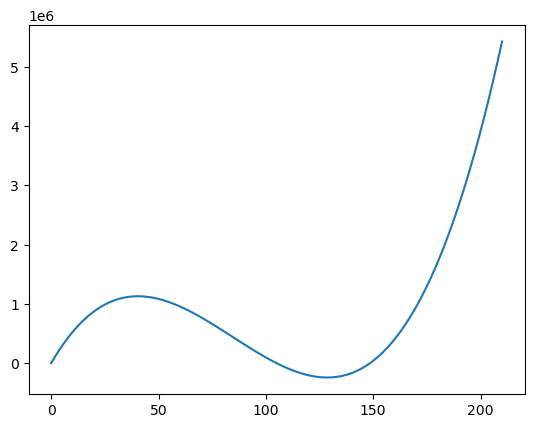

In [ ]:
x = np.linspace(0.0,210.0,100)
plt.plot(x,f(x))

# Newton

In [ ]:
from ene300 import newton_method

In [ ]:
newton_method(f_, 60.0, 0.0001)

Iteration 0: x = 32.602040816326536, f(x) = -955800.0
Iteration 1: x = 39.83400310576452, f(x) = -1094225.6498142781
Iteration 2: x = 40.41947395823086, f(x) = -1128310.5687480466
Iteration 3: x = 40.42336202570495, f(x) = -1128495.0967346
Iteration 4: x = 40.423362197191125, f(x) = -1128495.1047312554


40.423362197191125